# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [ ]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [ ]:
# PRELUDE: Load and Prepare Milestone 1 Dataset

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


 We dropped propertyzoningdesc column in the dataset: it has 1,907 unique values, and 544 (28.5%) appear only once in the dataset. If a code shows up only once, there's no way to tell whether its value is a real pattern or just a coincidence, since there's nothing else to compare it to. This makes over a quarter of the feature's categories essentially unusable. It's also a raw zoning code (e.g. LAR1, LAR3) where much of the remaining variety is just density tiers within the same city, not distinct property types. One-hot encoding it alone added around 1,907 columns, pushing our total to 2,744 and causing a MemoryError (around 1.05 GB) when converting to a DataFrame. Dropping it brought the total to 1,096 columns (around 0.44 GB), resolving the error. Location is still captured through fips, regionidcity, regionidzip, and regionidneighborhood.

In [ ]:
# showing the number of unique values in the 'propertyzoningdesc' column to explain why we are dropping it from the dataset
# new in milestone 2, not in milestone 1
print("Number of unique values in 'propertyzoningdesc':", df['propertyzoningdesc'].nunique())

value_counts_propertyzoningdesc = df['propertyzoningdesc'].value_counts()

print("Number of rows with unique 'propertyzoningdesc'values:", (value_counts_propertyzoningdesc == 1).sum())  # 544

Number of unique values in 'propertyzoningdesc': 1907
Number of rows with unique 'propertyzoningdesc'values: 544


 We also dropped regionidneighborhood and regionidzip before encoding, in addition to propertyzoningdesc. regionidneighborhood has 480 unique values and 60.1% missing — already our weakest location feature,  and alone produced 459 of our 1,096 encoded columns (42%). regionidzip has low missingness (0.1%) and genuine signal, but its 389 unique values added another 382 columns. Together these two features were the main driver of long training times (Ridge alone took over 10 minutes, HistGradientBoosting over 15 minutes). We retain location signal through fips (county) and regionidcity (city), which capture similar geographic information at much lower cardinality.

In [ ]:
# Milestone 1 imputation and encoding steps are performed here to prepare the dataset for modeling below.

# 3A: drop unsuitable features
df_suitable = df.drop(columns=['parcelid', 'assessmentyear', 'rawcensustractandblock', 'censustractandblock'])

# 3B: drop features missing more than 70%
missing_pct = df_suitable.isnull().mean() * 100
threshold = 70.0
columns_to_drop = missing_pct[missing_pct > threshold].index
df_missing = df_suitable.drop(columns=columns_to_drop)

# 3C: remove problematic samples
df_cleaned = df_missing.dropna(subset=["taxvaluedollarcnt"])
df_cleaned.dropna(thresh=20, inplace=True)

# 3D: train test split
X = df_cleaned.drop(columns=["taxvaluedollarcnt"])
y = df_cleaned["taxvaluedollarcnt"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# 3E: imputation
X_train_header = X_train.columns.to_list()
missing_cols = []
for col in X_train_header:
    if X_train[col].isna().sum() != 0:
        missing_cols += [col]

below_five = []
for col in missing_cols:
    per = (X_train[col].isna().sum() / len(X_train)) * 100
    if per < 5:
        below_five += [col]

X_train.dropna(subset=below_five, inplace=True)
X_test.dropna(subset=below_five, inplace=True)
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

X_train["garagecarcnt"] = X_train["garagecarcnt"].fillna(0)
X_train["garagetotalsqft"] = X_train["garagetotalsqft"].fillna(0)
X_test["garagecarcnt"] = X_test["garagecarcnt"].fillna(0)
X_test["garagetotalsqft"] = X_test["garagetotalsqft"].fillna(0)

mode_cols = ["unitcnt", "regionidneighborhood", "heatingorsystemtypeid", "buildingqualitytypeid", "airconditioningtypeid"]
mode_imputer = SimpleImputer(strategy="most_frequent")
mode_imputer.fit(X_train[mode_cols])
X_train[mode_cols] = mode_imputer.transform(X_train[mode_cols])
X_test[mode_cols] = mode_imputer.transform(X_test[mode_cols])

# drop propertyzoningdesc due to extreme cardinality (see discussion above)
X_train = X_train.drop(columns=['propertyzoningdesc'])
X_test = X_test.drop(columns=['propertyzoningdesc'])

# drop additional high-cardinality location columns due to runtime constraints (see discussion above)
X_train = X_train.drop(columns=['regionidneighborhood'])
X_test = X_test.drop(columns=['regionidneighborhood'])

# drop regionidzip due to runtime constraints (see discussion above)
X_train = X_train.drop(columns=['regionidzip'])
X_test = X_test.drop(columns=['regionidzip'])

# 3F: encoding, fit encoder using only training data
categorical_ordinal = ["buildingqualitytypeid"]
categorical_nominal = ["regionidcity", "regionidcounty",
                        "airconditioningtypeid", "fips", "heatingorsystemtypeid",
                        "propertylandusetypeid", "propertycountylandusecode"]

# importing Column Transformer and OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(), categorical_ordinal),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), categorical_nominal),
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# create as DataFrame for easier handling and to maintain column names
feature_names = preprocessor.get_feature_names_out()

X_train_encoded = pd.DataFrame(X_train_encoded.toarray(), columns=feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded.toarray(), columns=feature_names, index=X_test.index)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

print("Missing values X_train_encoded:", X_train_encoded.isnull().sum().sum())
print("Missing values X_test_encoded:", X_test_encoded.isnull().sum().sum())

print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])
print("Shapes match:", X_train_encoded.shape[1] == X_test_encoded.shape[1])  # should be True

# scaling, fit on training data only, needed for Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

/tmp/ipykernel_1913/2289309283.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(thresh=20, inplace=True)


X_train_encoded shape: (51219, 255)
X_test_encoded shape: (12812, 255)
Missing values X_train_encoded: 0
Missing values X_test_encoded: 0
Number of features in X_train_encoded: 255
Number of features in X_test_encoded: 255
Shapes match: True
X_train_scaled shape: (51219, 255)
X_test_scaled shape: (12812, 255)


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [ ]:
# Add as many code cells as needed.
from sklearn.metrics import mean_absolute_error

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

results_log = []
# accumulates every model result across the whole notebook

def evaluate_model(model, X, y, model_name, stage, cv=cv):
    """
    Fits a model, computes train MAE and repeated-CV MAE, times it,
    and logs the result for later comparison across all parts.
    """
    start = time.time()
    model.fit(X, y)
    train_mae = mean_absolute_error(y, model.predict(X))
    cv_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    elapsed = time.time() - start

    result = {
        "model": model_name,
        "stage": stage,
        "train_mae": train_mae,
        "cv_mae_mean": cv_scores.mean(),
        "cv_mae_std": cv_scores.std(),
        "time_seconds": elapsed
    }
    results_log.append(result)
    print(f"{stage} {model_name}: train MAE={train_mae:.0f}, CV MAE={cv_scores.mean():.0f}, "
          f"CV MAE Standard Deviation={cv_scores.std():.0f}, time={elapsed:.1f}s")
    return result

In [ ]:
# run the model evaluation function for each model on the training data

# Three models selected for evaluation are Ridge Regression, Decision Tree, and HistGradientBoostingRegressor.
# The reason for selecting these models is to compare a linear model (Ridge Regression) with
# two tree-based models (Decision Tree and HistGradientBoostingRegressor) to see how they perform on the dataset.
# Also, these 3 models are comparatively less complex and faster to train than some other models,
# making them suitable for initial evaluation.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

evaluate_model(Ridge(), X_train_scaled, y_train, "Ridge", "Part 1 Baseline")

evaluate_model(DecisionTreeRegressor(random_state=random_state), X_train_encoded, y_train, "Decision Tree", "Part 1 Baseline")

evaluate_model(HistGradientBoostingRegressor(random_state=random_state), X_train_encoded, y_train, "HistGradientBoosting", "Part 1 Baseline");

Part 1 Baseline Ridge: train MAE=234516, CV MAE=235926, CV MAE Standard Deviation=2601, time=5.8s
Part 1 Baseline Decision Tree: train MAE=2108, CV MAE=262102, CV MAE Standard Deviation=3317, time=36.9s
Part 1 Baseline HistGradientBoosting: train MAE=185942, CV MAE=200120, CV MAE Standard Deviation=2735, time=153.9s


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score**?

> Based on the model performance results above, HistGradientBoosting had the lowest CV MAE (200,236 dollars), beating Ridge (235,926 dollars) and Decision Tree (262,102 dollars).

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

> Ridge produced the smallest standard deviation (std=2,601 dollars), compared to HistGradientBoosting (std=2,895 dollars) and Decision Tree (std=3,317 dollars). This suggests Ridge is the most stable of the three, and its performance stays consistent regardless of which properties land in training vs. validation, likely because its regularization keeps extreme outlier values from swinging the fit much from fold to fold.

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

> Comparing train MAE to CV MAE tells us whether a model is overfitting: if train MAE is much lower than CV MAE, the model fits the training data closely but fails to generalize to unseen data (overfitting). If both are high and similar, the model isn't capturing the pattern well at all (underfitting). Decision Tree appears to overfit strongly: train MAE (2,108 dollars) is about 100 times smaller than CV MAE (262,102 dollars), fitting a tree's typical behavior of memorizing individual properties, including outliers, instead of learning a general pattern. Ridge shows no real overfitting (train 234,516 dollars vs CV 235,926 dollars) due to regularization. HistGradientBoosting shows mild overfitting (train 186,689 dollars vs CV 200,236 dollars), likely because boosting focuses on cases like outliers, but the gap is much smaller than Decision Tree's.

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

> No single model was best across both accuracy and stability, and there's a real tradeoff between them. HistGradientBoosting had the lowest (best) CV MAE at 200,236 dollars, while Decision Tree had the highest (worst) at 262,102 dollars, a difference of over 60,000 dollars. On stability, Ridge had the lowest (best) standard deviation at 2,601 dollars, while Decision Tree again had the highest (worst) at 3,317 dollars. HistGradientBoosting is best on accuracy but not quite the most stable. Ridge has better stability but worse accuracy. Decision Tree is the weakest on both measures simultaneously.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats).
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [ ]:
from sklearn.metrics import make_scorer

models_p2 = {
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=random_state),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_state)
}

# Idea 1: Remove redundant features
drop_cols = ['remainder__calculatedbathnbr', 'remainder__fullbathcnt', 'remainder__finishedsquarefeet12']
X_train_idea1 = X_train_encoded.drop(columns=drop_cols)

for name, model in models_p2.items():
    if name == "Ridge":
        X_data = StandardScaler().fit_transform(X_train_idea1)
    else:
        X_data = X_train_idea1
    evaluate_model(model, X_data, y_train, name, "Part 2 - Redundant Removed")

#  Idea 2: Log transform target and skewed features
log_feature_cols = ['remainder__calculatedfinishedsquarefeet', 'remainder__lotsizesquarefeet']
X_train_idea2 = X_train_encoded.copy()
for col in log_feature_cols:
    X_train_idea2[col] = np.log1p(X_train_idea2[col])
y_train_log = np.log1p(y_train)

# y_true_log is the actual real target value (log-form) for the held-out rows,
# and y_pred_log is the model's prediction (also log-form) for those same rows,
# and cross_val_score's scoring= parameter
# is what tells it to hand both of these to our custom function, instead of using its default scoring method
def log_mae_scorer(y_true_log, y_pred_log):
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_actual, y_pred_actual)

custom_scorer = make_scorer(log_mae_scorer, greater_is_better=False)

for name, model in models_p2.items():
    if name == "Ridge":
        X_data = StandardScaler().fit_transform(X_train_idea2)
    else:
        X_data = X_train_idea2

    start = time.time()

    # fit once on full training data to get train MAE (back-transformed to dollars)
    model.fit(X_data, y_train_log)
    train_pred_log = model.predict(X_data)
    train_pred_actual = np.expm1(train_pred_log)
    train_mae = mean_absolute_error(y_train, train_pred_actual)

    # repeated CV for validation MAE, using our custom back-transforming scorer
    scores = cross_val_score(model, X_data, y_train_log, cv=cv, scoring=custom_scorer)
    mae_scores = -scores

    elapsed = time.time() - start

    print(f"Part 2 - Log Transform {name}: train MAE={train_mae:.2f}, "
          f"CV MAE mean={mae_scores.mean():.2f}, CV MAE std={mae_scores.std():.2f}, time={elapsed:.1f}s")

# Idea 3: Scaling comparison
for name, model in models_p2.items():
    X_scaled = StandardScaler().fit_transform(X_train_encoded)
    evaluate_model(model, X_scaled, y_train, name, "Part 2 - Scaled")

Part 2 - Redundant Removed Ridge: train MAE=234476, CV MAE=235880, CV MAE Standard Deviation=2612, time=5.9s
Part 2 - Redundant Removed Decision Tree: train MAE=2108, CV MAE=262427, CV MAE Standard Deviation=3793, time=32.2s
Part 2 - Redundant Removed HistGradientBoosting: train MAE=184649, CV MAE=200186, CV MAE Standard Deviation=2756, time=156.1s
Part 2 - Log Transform Ridge: train MAE=212439.42, CV MAE mean=213939.49, CV MAE std=5152.58, time=6.7s
Part 2 - Log Transform Decision Tree: train MAE=2139.85, CV MAE mean=265352.18, CV MAE std=4085.97, time=30.2s
Part 2 - Log Transform HistGradientBoosting: train MAE=194035.22, CV MAE mean=201881.80, CV MAE std=3259.44, time=191.0s
Part 2 - Scaled Ridge: train MAE=234516, CV MAE=235926, CV MAE Standard Deviation=2601, time=5.8s
Part 2 - Scaled Decision Tree: train MAE=2107, CV MAE=262525, CV MAE Standard Deviation=3505, time=35.4s
Part 2 - Scaled HistGradientBoosting: train MAE=185942, CV MAE=200120, CV MAE Standard Deviation=2735, time=15

### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

> Part 1 baseline results, for reference: Ridge: train MAE=234,516 dollars, CV MAE=235,926 dollars, CV MAE std=2,601 dollars; Decision Tree: train MAE=2,108 dollars, CV MAE=262,102 dollars, CV MAE std=3,317 dollars; HistGradientBoosting: train MAE=186,689 dollars, CV MAE=200,236 dollars, CV MAE std=2,895 dollars. In part 2, we tested three ideas from Milestone 1: removing redundant features, log-transforming the target and skewed features, and scaling. Compared to the Part 1 baseline, the log transform produced the largest improvement, but only for Ridge: CV MAE dropped from 235,926 dollars to 213,939 dollars, roughly a 9% improvement. Neither redundant feature removal nor scaling produced a meaningful improvement for any model relative to their respective baselines.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

> Redundant feature removal had essentially no effect on any model, as both train and CV MAE stayed roughly the same across the board, which makes sense since the dropped columns were duplicates. Scaling (Idea 3) was run on all three models for consistency, though Ridge already requires scaling regardless of what this test shows, so an "unscaled Ridge" comparison isn't meaningful for evaluating the hypothesis — the more informative comparison is for Decision Tree and HistGradientBoosting. Both tree-based models showed no meaningful difference between scaled and unscaled versions, confirming that scaling doesn't affect their performance. The log transform showed mixed results. For Decision Tree, both train and CV MAE got slightly worse, and its already-severe overfitting got a bit worse too. For HistGradientBoosting, CV MAE dipped very slightly, but the gap between train and CV MAE shrank noticeably, which is a real improvement in overfitting, even though raw accuracy barely moved.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

> Yes, Ridge was the only model that benefited from feature engineering, specifically from the log transform. This makes sense given how each model works: Ridge fits a straight-line relationship between features and target, so reducing the target's skew directly helps it find a better-fitting line. Decision Tree and HistGradientBoosting instead split the data based on thresholds in the raw feature values, so they don't rely on the target's distribution shape the same way, and the log transform provided no benefit and even slightly hurt their performance.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

> Idea 1 (redundant feature removal): We will keep this for all three models, since it simplifies the feature set without any measurable downside to train or CV MAE. Idea 2 (log transform): We will keep this for Ridge, since it clearly improved both train and CV MAE. We will also keep it for HistGradientBoosting, since although CV MAE was marginally worse, the meaningfully reduced overfitting gap suggests better generalization potential, which we consider more valuable heading into Part 4's tuning. We will not apply it for Decision Tree, since it worsened both CV MAE and overfitting with no offsetting benefit. Idea 3 (scaling): Ridge will continue to be scaled, as required for the model to function correctly, though our test confirmed this doesn't meaningfully change its performance. Decision Tree and HistGradientBoosting will remain unscaled, since scaling has no effect on tree-based models.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [ ]:
# feature engineering changes from part 2

# dropping redundant cols for all model (Idea 1)
drop_cols = ['remainder__calculatedbathnbr','remainder__fullbathcnt','remainder__finishedsquarefeet12']
X_train_three = X_train_encoded.drop(columns=drop_cols)
X_tree = X_train_three.copy()
y_tree = y_train.copy()

# log transformation for ridge regression and histgradientboosting (Idea 2)
log_feature_cols = ['remainder__calculatedfinishedsquarefeet', 'remainder__lotsizesquarefeet']

X_ridge = X_train_three.copy()
X_hist = X_train_three.copy()

for col in log_feature_cols:
    X_ridge[col] = np.log1p(X_ridge[col])
    X_hist[col] = np.log1p(X_hist[col])

y_ridge = np.log1p(y_train)
y_hist = np.log1p(y_train)

# scaling for ridge regression (Idea 3)
X_ridge_scaled = scaler.fit_transform(X_ridge)
X_ridge_columns = X_ridge.columns

In [ ]:
# Ridge Regression Prior to Feature Selection
ridge = Ridge( random_state=random_state)
ridge.fit(X_ridge_scaled, y_ridge)

# Training predictions
train_pred_log = ridge.predict(X_ridge_scaled)
train_pred_actual = np.expm1(train_pred_log)

train_mae = mean_absolute_error(y_train, train_pred_actual)


rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

# repeated 5 fold cv
scores = cross_val_score(
    ridge,
    X_ridge_scaled,
    y_ridge,
    cv=rkf,
    scoring=custom_scorer
)

mae_scores = -scores

print(
    f"Ridge Regression: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

Ridge Regression: train MAE=210298.62, CV MAE mean=211557.52, CV MAE std=2892.83


In [ ]:
# Forward selection (Ridge Regression)
ridge = Ridge()

# preforms forward selection
sfs = SequentialFeatureSelector(
    ridge,
    n_features_to_select=15,
    direction="forward",
    scoring=custom_scorer,
    cv=cv,
    n_jobs=-1
)

sfs.fit(X_ridge_scaled, y_ridge)

# get subset of features
selected_index = sfs.get_support(indices=True)
selected_features = X_ridge.columns[selected_index]
print(f"Forward Selection Best Features: {selected_features.tolist()}") # prints out the best features subset found


# retrain the model
X_ridge_selected = X_ridge_scaled[:, selected_index]

# compare feature counts
print("Original number of features:", X_ridge.shape[1])
print("Selected number of features:", X_ridge_selected.shape[1])

ridge_selected = Ridge()
ridge_selected.fit(X_ridge_selected, y_ridge)

# calculate mae
train_pred_log = ridge_selected.predict(X_ridge_selected)
train_pred_actual = np.expm1(train_pred_log)

train_mae = mean_absolute_error(y_train, train_pred_actual)

# same repeated cross-validation from part 2
scores = cross_val_score(
    ridge_selected,
    X_ridge_selected,
    y_ridge,
    cv=cv,
    scoring=custom_scorer
)

mae_scores = -scores

# Report data
print(
    f"Part 3 - Ridge Forward Selection: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

Forward Selection Best Features: ['ordinal__buildingqualitytypeid', 'nominal__regionidcity_5534.0', 'nominal__regionidcity_19177.0', 'nominal__regionidcity_26964.0', 'nominal__regionidcity_40009.0', 'nominal__regionidcity_40227.0', 'nominal__regionidcity_52650.0', 'nominal__regionidcity_53571.0', 'nominal__propertycountylandusecode_1', 'remainder__bathroomcnt', 'remainder__bedroomcnt', 'remainder__calculatedfinishedsquarefeet', 'remainder__latitude', 'remainder__longitude', 'remainder__roomcnt']
Original number of features: 252
Selected number of features: 15
Part 3 - Ridge Forward Selection: train MAE=219463.44, CV MAE mean=219579.50, CV MAE std=3273.47


In [ ]:
# HistGradientBoosting Prior to feature selection

# train model
hgb = HistGradientBoostingRegressor(random_state=random_state)
hgb.fit(X_hist, y_hist)

# predictions
train_pred_log = hgb.predict(X_hist)
train_pred_actual = np.expm1(train_pred_log)

train_mae = mean_absolute_error(y_train, train_pred_actual)

# repeated 5 fold CV
scores = cross_val_score(
    hgb,
    X_hist,
    y_hist,
    cv=rkf,
    scoring=custom_scorer
)

mae_scores = -scores

print(
    f"HistGradientBoosting: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

HistGradientBoosting: train MAE=193994.11, CV MAE mean=202030.49, CV MAE std=3315.37


In [ ]:
# HistGradientBoosting
hgb = HistGradientBoostingRegressor(random_state=random_state)
hgb.fit(X_hist, y_hist)

from sklearn.inspection import permutation_importance

# permutation importance since HistGradientBoosting does not have feature selection
hist_result = permutation_importance(
    hgb,
    X_hist,
    y_hist,
    scoring=custom_scorer,
    n_repeats=5,
    random_state=random_state,
    n_jobs=-1
)

# sort from most to least important features
hist_importance = pd.Series(hist_result.importances_mean, index=X_hist.columns).sort_values(ascending=False)

# get features with an importance over 0
best_features = hist_importance[hist_importance > 0].index.tolist()
print(f"Selected HistGradientBoosting Features: {best_features}")

# new X_train with feature selection
X_hist_selected = X_hist[best_features]

# compare feature counts
print("Original number of features:", X_hist.shape[1])
print("Selected number of features:", X_hist_selected.shape[1])

# retrain model
hgb_selected = HistGradientBoostingRegressor(random_state=random_state)
hgb_selected.fit(X_hist_selected, y_hist)

# calculate mae
train_pred_log = hgb_selected.predict(X_hist_selected)
train_pred_actual = np.expm1(train_pred_log)

train_mae = mean_absolute_error(y_train, train_pred_actual)

# same repeated cross-validation from part 2
scores = cross_val_score(
    hgb_selected,
    X_hist_selected,
    y_hist,
    cv=cv,
    scoring=custom_scorer
)

mae_scores = -scores

# Report data
print(
    f"Part 3 - HistGradientBoosting Permutation Importance: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

Selected HistGradientBoosting Features: ['remainder__calculatedfinishedsquarefeet', 'remainder__latitude', 'remainder__longitude', 'remainder__yearbuilt', 'remainder__bathroomcnt', 'ordinal__buildingqualitytypeid', 'remainder__lotsizesquarefeet', 'nominal__regionidcity_53571.0', 'nominal__propertycountylandusecode_0101', 'remainder__bedroomcnt', 'nominal__regionidcity_12520.0', 'remainder__garagetotalsqft', 'nominal__propertycountylandusecode_0103', 'nominal__regionidcity_52842.0', 'nominal__regionidcity_40009.0', 'nominal__regionidcity_19177.0', 'nominal__propertycountylandusecode_010C', 'nominal__regionidcity_46080.0', 'nominal__propertycountylandusecode_1111', 'nominal__regionidcity_52650.0', 'nominal__regionidcity_13150.0', 'nominal__propertycountylandusecode_010G', 'nominal__propertycountylandusecode_1110', 'nominal__propertylandusetypeid_261.0', 'nominal__regionidcity_25218.0', 'nominal__regionidcity_54299.0', 'nominal__regionidcity_47019.0', 'nominal__propertycountylandusecode_0

In [ ]:
# Decision Tree Prior to feature selection
# train model
tree = DecisionTreeRegressor(random_state=random_state)
tree.fit(X_tree, y_tree)

# predictions
train_pred = tree.predict(X_tree)

train_mae = mean_absolute_error(y_train, train_pred)

# repeated 5 fold CV
scores = cross_val_score(
    tree,
    X_tree,
    y_tree,
    cv=rkf,
    scoring="neg_mean_absolute_error"
)

mae_scores = -scores

print(
    f"Decision Tree: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

Decision Tree: train MAE=2107.59, CV MAE mean=262426.66, CV MAE std=3792.56


In [ ]:
# Decision Tree
tree = DecisionTreeRegressor(random_state=random_state)
tree.fit(X_tree, y_tree)


tree_importance = pd.Series(tree.feature_importances_, index=X_tree.columns).sort_values(ascending=False)

# keep features with importance greater than 0.01
threshold = 0.01
tree_selected_features = tree_importance[tree_importance > threshold].index.tolist()
print(f"Selected Decision Tree Features: {tree_selected_features}")

# new X_train with selected features
X_tree_selected = X_tree[tree_selected_features]

# compare feature counts
print("Original number of features:", X_tree.shape[1])
print("Selected number of features:", X_tree_selected.shape[1])

# retrain model
tree_selected_model = DecisionTreeRegressor(random_state=random_state)
tree_selected_model.fit(X_tree_selected, y_tree)
train_pred_actual = tree_selected_model.predict(X_tree_selected)
train_mae = mean_absolute_error(y_tree, train_pred_actual)

# same repeated cross-validation procedure from Part 2
scores = cross_val_score(
    tree_selected_model,
    X_tree_selected,
    y_tree,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

mae_scores = -scores

# Report data
print(
    f"Part 3 - Decision Tree Feature Importance: "
    f"train MAE={train_mae:.2f}, "
    f"CV MAE mean={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

Selected Decision Tree Features: ['remainder__calculatedfinishedsquarefeet', 'remainder__latitude', 'remainder__longitude', 'remainder__yearbuilt', 'remainder__lotsizesquarefeet', 'ordinal__buildingqualitytypeid', 'remainder__bathroomcnt', 'remainder__bedroomcnt', 'nominal__regionidcity_12520.0', 'nominal__regionidcity_53571.0']
Original number of features: 252
Selected number of features: 10
Part 3 - Decision Tree Feature Importance: train MAE=2116.56, CV MAE mean=265512.77, CV MAE std=4368.71


In [ ]:
# features in at least two models
ridge_set = set(selected_features.tolist())
tree_set = set(tree_selected_features)
hist_set = set(best_features)

# seeing cases where the feature is in both
at_least_two = (
    (ridge_set & tree_set)
    | (ridge_set & hist_set)
    | (tree_set & hist_set)
)

print(sorted(at_least_two))

['nominal__regionidcity_12520.0', 'nominal__regionidcity_19177.0', 'nominal__regionidcity_26964.0', 'nominal__regionidcity_40009.0', 'nominal__regionidcity_52650.0', 'nominal__regionidcity_53571.0', 'nominal__regionidcity_5534.0', 'ordinal__buildingqualitytypeid', 'remainder__bathroomcnt', 'remainder__bedroomcnt', 'remainder__calculatedfinishedsquarefeet', 'remainder__latitude', 'remainder__longitude', 'remainder__lotsizesquarefeet', 'remainder__roomcnt', 'remainder__yearbuilt']


In [ ]:
# features that were flagged as important in all models
three_times = (ridge_set & tree_set & hist_set)
print(three_times)

{'remainder__bedroomcnt', 'remainder__longitude', 'ordinal__buildingqualitytypeid', 'remainder__calculatedfinishedsquarefeet', 'remainder__bathroomcnt', 'remainder__latitude', 'nominal__regionidcity_53571.0'}


In [ ]:
# checking if engineered features were selected as important
combined_features = (selected_features.tolist()+ tree_selected_features + best_features)
print(f"calculatedfinishedsquarefeet selected as a best feature? {'remainder__calculatedfinishedsquarefeet' in combined_features}")
print(f"lotsizesquarefeet selected as a best feature? {'remainder__lotsizesquarefeet' in combined_features}")

calculatedfinishedsquarefeet selected as a best feature? True
lotsizesquarefeet selected as a best feature? True


### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

Results from preprocessing decisions from Part 2:
- Ridge Regression: train MAE=210298.62, CV MAE mean=211557.52, CV MAE std=2892.83
- HistGradientBoosting: train MAE=193994.11, CV MAE mean=202030.49, CV MAE std=3315.37
- Decision Tree: train MAE=2107.59, CV MAE mean=262426.66, CV MAE std=3792.56

Part 3 results for reference:
- Ridge Forward Selection: train MAE=219463.44, CV MAE mean=219579.50, CV MAE std=3273.47
- HistGradientBoosting Permutation Importance: train MAE=193824.80, CV MAE mean=201736.80, CV MAE std=3411.10
- Decision Tree Feature Importance: train MAE=2116.56, CV MAE mean=265512.77, CV MAE std=4368.71


> For our feature selection, we first chose to use forward selection on our Ridge Regression model, which selected 15 features. This is because, when testing feature counts in increments of five, 15 features was the largest number that improved the MAE in a reasonable amount of time. Higher feature counts increased the runtime by at least 40% and provided little improvement compared to our 15 count model. For our HistGradientBoosting model, we chose a feature importance threshold greater than 0, since features with an importance above 0 indicate predictive value. Likewise, we chose a threshold of 0.01 for our Decision Tree model to reduce overfitting, as we found that higher thresholds, such as 0.05, performed worse. Comparing the results of our feature selection to our baseline values, we found that only the HistGradientBoosting model showed an improvement, the lower Train and CV MAE still suggest that feature selection improved the HistGradientBoosting model overall. On the other hand, the feature selection models for RidgeRegression and Decision Tree performed worse than their non feature selected models, suggesting that we removed features that were valuable for these models.

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

> We found that features nominal__regionidcity_12520.0, nominal__regionidcity_19177.0, nominal__regionidcity_26964.0, nominal__regionidcity_40009.0, nominal__regionidcity_52650.0, nominal__regionidcity_53571.0, nominal__regionidcity_5534.0, ordinal__buildingqualitytypeid, remainder__bathroomcnt, remainder__bedroomcnt, remainder__calculatedfinishedsquarefeet, remainder__latitude, remainder__longitude, remainder__lotsizesquarefeet, remainder__roomcnt, and remainder__yearbuilt, were retained in at least two of our models after feature selection. Further, remainder__latitude, remainder__longitude, remainder__bathroomcnt, remainder__bedroomcnt, and remainder__calculatedfinishedsquarefeet, were reatined in all three of our models, conveying heavy importance. Conversely, all remaining features were removed by all three models, conveying that they contribute less to model performance.

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> Based on our findings from Milestone 1, we decided to do log transformation on two features, remainder__calculatedfinishedsquarefeet and remainder__lotsizesquarefeet for Ridge Regression and HistGradientBoosting. Both of these engineered features were selected as important and remainder__calculatedfinishedsquarefeet was selected as important in both models. This suggests that our hypothesis was supported and that the log transformation brought our skewness down and preserved importance for these features in our models.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

> After feature selection, we found that only HistGradientBoosting had any improvements, as the Train and CV MAE decreased. However, a tradeoff with our feature selection was that the standard deviation increased compared to the models from our preprocessing decision from Part 2. In contrast, we found that the simpler RidgeRegression and Decision Tree models performed worse across all metrics, showing that the more complex models performed better. Due to this, we will not be using the feature selection for RidgeRegression and DecisionTree, but will be for HistGradientBoosting.

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats).
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [ ]:
# parameter tuning for ridge regression using gridsearchcv
alpha_grid = {
    "alpha": [3, 4, 5, 6]
}

ridge = Ridge()

# 5 fold cv
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=alpha_grid,
    cv=5,
    scoring=custom_scorer
)

grid_search.fit(X_ridge, y_ridge)

# best alpha
best_alpha = grid_search.best_params_["alpha"]
print(f"Best alpha: {best_alpha:.15f}")

# create the tuned ridge model
best_ridge = Ridge(alpha=best_alpha)

# repeated 5 fold cv
rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

mae_scores = -cross_val_score(
    best_ridge,
    X_ridge_selected,
    y_ridge,
    scoring=custom_scorer,
    cv=rkf
)

# report data
print(
    f"Part 4 - Tuned Ridge Regression: "
    f"Best alpha={best_alpha:.15f}, "
    f"CV MAE mean={mae_scores.mean():.6f}, "
    f"CV MAE std={mae_scores.std():.6f}"
)

Best alpha: 4.000000000000000
Part 4 - Tuned Ridge Regression: Best alpha=4.000000000000000, CV MAE mean=219581.429289, CV MAE std=3273.802878


In [ ]:
# from HW7 (used for HistGradientBoosting tuning)

random_seed = random_state
def run_model(model,
              X_train, y_train,
              n_repeats=5,
              n_jobs=-1,
              **model_params
             ):

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model,
        X_train, y_train,
        scoring=custom_scorer, # changed because of the log transformation
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_seed),
        n_jobs=n_jobs
    )

    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)

    # Fit the model on the full training set
    model.fit(X_train, y_train)

    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)

    return mean_cv_mae, std_cv_mae, train_mae

def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train,              # Defined above
                    y_train          = y_train,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = False,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):


    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary

    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')

    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  # Just in case

        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)

        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1

        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        if show_mae:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters

Sweeping learning_rate: 100%|██████████| 4/4 [03:22<00:00, 50.53s/it]


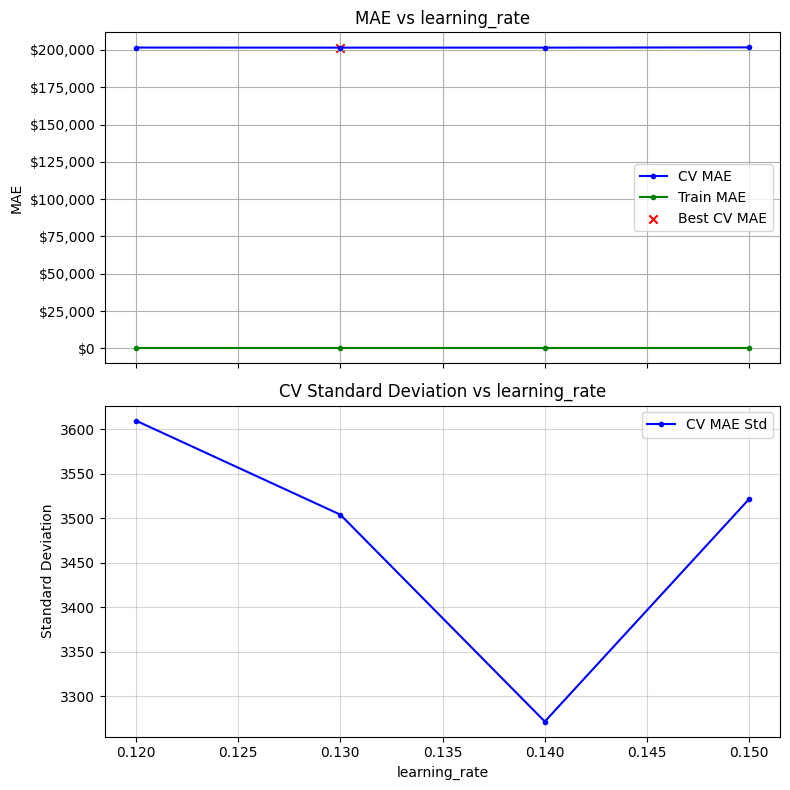

Execution Time: 00:03:22
{'random_state': 42, 'learning_rate': 0.13, 'max_leaf_nodes': 31, 'max_depth': None, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'MAE_found': np.float64(201568.34407234166)}


In [ ]:
# HistGradientBoosting learning_rate parameter tuning using sweep_parameter
params = {
    "random_state": random_state,
    "learning_rate": 0.1,
    "max_leaf_nodes": 31,
    "max_depth": None,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0
}

hist_params = sweep_parameter(
    model=HistGradientBoostingRegressor,
    Parameters=params,
    param="learning_rate",
    parameter_list=[0.12, 0.13, 0.14, 0.15],
    X_train=X_hist_selected,
    y_train=y_hist,
    show_std=True,
    n_repeats=5
)

print(hist_params)

Sweeping max_leaf_nodes: 100%|██████████| 3/3 [02:46<00:00, 55.48s/it]


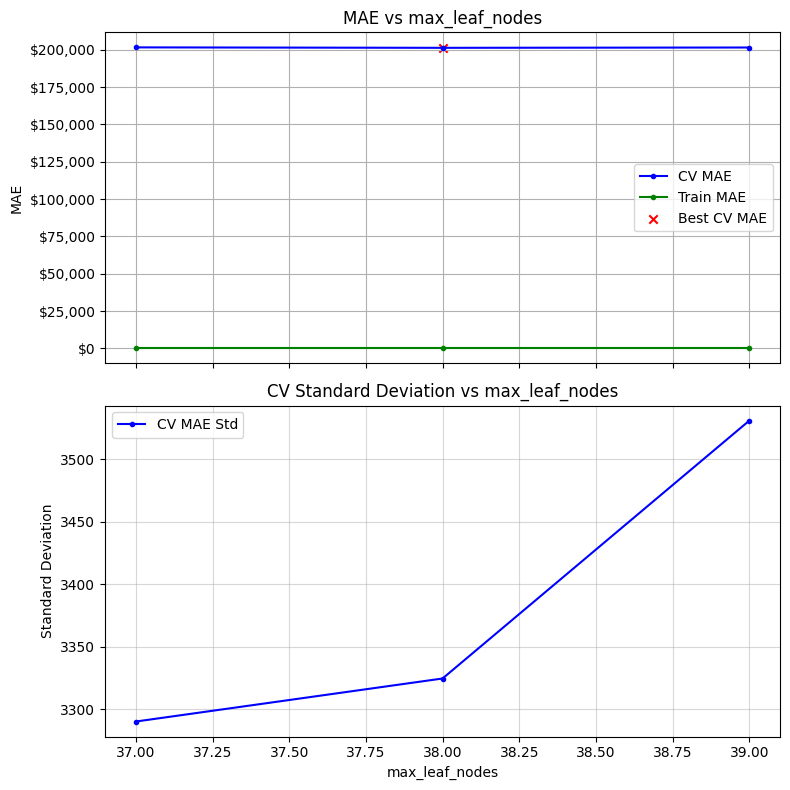

Execution Time: 00:02:46
{'random_state': 42, 'learning_rate': 0.13, 'max_leaf_nodes': 38, 'max_depth': None, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'MAE_found': np.float64(201342.33103329502)}


In [ ]:
# HistGradientBoosting max_leaf_nodes parameter tuning using sweep_parameter
params = {
    "random_state": random_state,
    "learning_rate": 0.13,
    "max_leaf_nodes": 31,
    "max_depth": None,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0
}

hist_params = sweep_parameter(
    model=HistGradientBoostingRegressor,
    Parameters=params,
    param="max_leaf_nodes",
    parameter_list=[37, 38, 39],
    X_train=X_hist_selected,
    y_train=y_hist,
    show_std=True,
    n_repeats=5
)

print(hist_params)

Sweeping min_samples_leaf: 100%|██████████| 3/3 [02:33<00:00, 51.32s/it]


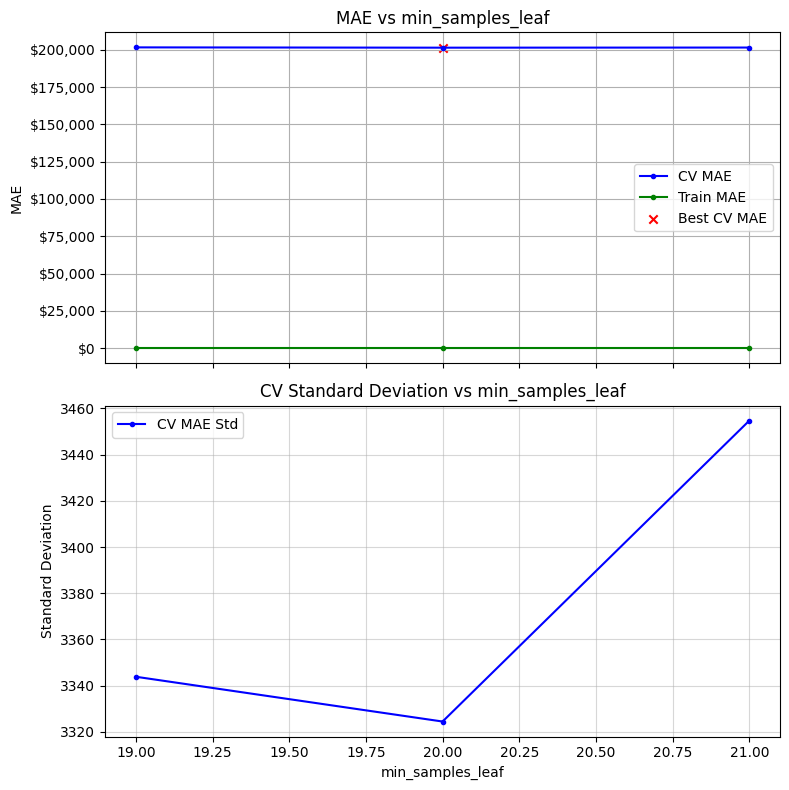

Execution Time: 00:02:34
{'random_state': 42, 'learning_rate': 0.13, 'max_leaf_nodes': 38, 'max_depth': None, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'MAE_found': np.float64(201342.33103329502)}


In [ ]:
# HistGradientBoosting min_samples_leaf parameter tuning using sweep_parameter
params = {
    "random_state": random_state,
    "learning_rate": 0.13,
    "max_leaf_nodes": 38,
    "max_depth": None,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0
}

hist_params = sweep_parameter(
    model=HistGradientBoostingRegressor,
    Parameters=params,
    param="min_samples_leaf",
    parameter_list=[19, 20, 21],
    X_train=X_hist_selected,
    y_train=y_hist,
    show_std=True,
    n_repeats=5
)
print(hist_params)

Sweeping l2_regularization: 100%|██████████| 4/4 [03:26<00:00, 51.67s/it]


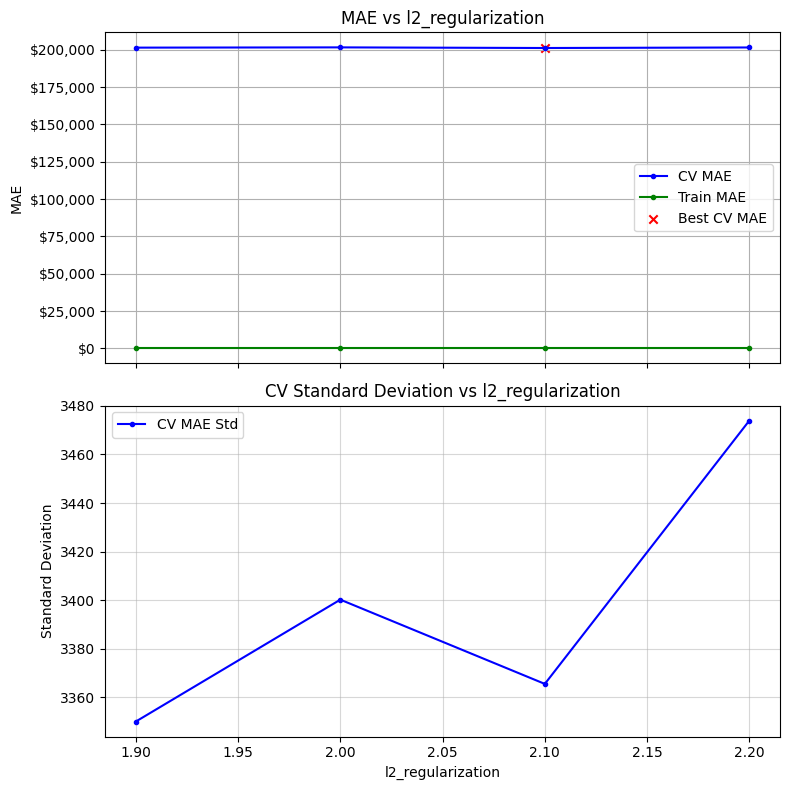

Execution Time: 00:03:26
{'random_state': 42, 'learning_rate': 0.13, 'max_leaf_nodes': 38, 'max_depth': None, 'min_samples_leaf': 20, 'l2_regularization': 2.1, 'MAE_found': np.float64(201239.0780119076)}


In [ ]:
# HistGradientBoosting l2_regularization parameter tuning using sweep_parameter
params = {
    "random_state": random_state,
    "learning_rate": 0.13,
    "max_leaf_nodes": 38,
    "max_depth": None,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0
}
hist_params = sweep_parameter(
    model=HistGradientBoostingRegressor,
    Parameters=params,
    param="l2_regularization",
    parameter_list=[1.9, 2.0, 2.1, 2.2],
    X_train=X_hist_selected,
    y_train=y_hist,
    show_std=True,
    n_repeats=5
)

print(hist_params)


In [ ]:
# 5 fold cv for tuning (using to avoid running for too long, faster than repeated)
from sklearn.model_selection import KFold
tuning_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

# repeated cv for final evaluation
rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

# based on parameter sweeping
hist_param_grid = {
    "learning_rate": [0.11, 0.13, 0.15],
    "max_leaf_nodes": [37, 38, 39],
    "min_samples_leaf": [15, 20, 25],
    "l2_regularization": [2.0, 2.1, 2.2, 2.3]
}

# retrain model
hist_grid = GridSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=random_state,
        max_depth=None
    ),
    param_grid=hist_param_grid,
    scoring=custom_scorer,
    cv=tuning_cv,
    n_jobs=-1,
    verbose=1
)

hist_grid.fit(X_hist_selected, y_hist)

best_hist = hist_grid.best_estimator_
final_hist_params = hist_grid.best_params_

hist_mae_scores = -cross_val_score(
    best_hist,
    X_hist_selected,
    y_hist,
    scoring=custom_scorer,
    cv=rkf,
    n_jobs=-1
)

print(
    f"Part 4 - Tuned HistGradientBoosting: "
    f"Parameters={final_hist_params}, "
    f"CV MAE mean={hist_mae_scores.mean():.2f}, "
    f"CV MAE std={hist_mae_scores.std():.2f}"
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Part 4 - Tuned HistGradientBoosting: Parameters={'l2_regularization': 2.1, 'learning_rate': 0.13, 'max_leaf_nodes': 38, 'min_samples_leaf': 20}, CV MAE mean=201239.08, CV MAE std=3365.49


In [ ]:
# to show how different parameters are affecting the cv score
hist_results = pd.DataFrame(hist_grid.cv_results_)
hist_results["cv_mae"] = -hist_results["mean_test_score"]

hist_results[[
    "param_learning_rate",
    "param_max_leaf_nodes",
    "param_min_samples_leaf",
    "param_l2_regularization",
    "cv_mae"
]].sort_values("cv_mae").head(15)

,param_learning_rate,param_max_leaf_nodes,param_min_samples_leaf,param_l2_regularization,cv_mae
40,0.13,38,20,2.1,200570.694203
65,0.13,37,25,2.2,200614.631233
17,0.13,39,25,2.0,200617.439481
35,0.11,39,25,2.1,200696.649021
61,0.11,39,20,2.2,200730.386868
8,0.11,39,25,2.0,200783.620372
14,0.13,38,25,2.0,200800.569980
41,0.13,38,25,2.1,200835.169478
29,0.11,37,25,2.1,200852.810486
32,0.11,38,25,2.1,200864.153744


In [ ]:
# parameter tunining for DecisionTree
tree_param_model = DecisionTreeRegressor(random_state=random_state)

tree_param_grid = {
    "max_depth": [10, 11, 12, 13, None],
    "min_samples_split": [25, 26, 27, 28, 29],
    "min_samples_leaf": [5, 6, 7, 8, 9]
}

grid_search = GridSearchCV(
    estimator=tree_param_model,
    param_grid=tree_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_tree, y_tree)
print("Best Parameters:", grid_search.best_params_)
best_tree = grid_search.best_estimator_

rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state
)

tree_mae_scores = -cross_val_score(
    best_tree,
    X_tree,
    y_tree,
    scoring="neg_mean_absolute_error",
    cv=rkf,
    n_jobs=-1
)

print(
    f"Part 4 - Tuned Decision Tree: "
    f"Parameters={grid_search.best_params_}, "
    f"CV MAE mean={tree_mae_scores.mean():.6f}, "
    f"CV MAE std={tree_mae_scores.std():.6f}"
)

Best Parameters: {'max_depth': 13, 'min_samples_leaf': 7, 'min_samples_split': 26}
Part 4 - Tuned Decision Tree: Parameters={'max_depth': 13, 'min_samples_leaf': 7, 'min_samples_split': 26}, CV MAE mean=215120.723805, CV MAE std=2119.024293


In [ ]:
tree_results = pd.DataFrame(grid_search.cv_results_)

tree_results["cv_mae"] = -tree_results["mean_test_score"]

tree_results[[
    "param_max_depth",
    "param_min_samples_leaf",
    "param_min_samples_split",
    "cv_mae"
]].sort_values("cv_mae").head(15)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,cv_mae
86,13,7,26,214476.587752
87,13,7,27,214494.786926
82,13,6,27,214609.479465
81,13,6,26,214637.534264
97,13,9,27,214644.162440
96,13,9,26,214648.760199
92,13,8,27,214653.030317
78,13,5,28,214670.506316
85,13,7,25,214685.431477
77,13,5,27,214697.408099


In [ ]:
# results summary
print(
    f"Part 4 - Tuned Ridge Regression: "
    f"CV MAE={mae_scores.mean():.2f}, "
    f"CV MAE std={mae_scores.std():.2f}"
)

print(
    f"Part 4 - Tuned HistGradientBoosting: "
    f"CV MAE={hist_mae_scores.mean():.2f}, "
    f"CV MAE std={hist_mae_scores.std():.2f}"
)

print(
    f"Part 4 - Tuned Decision Tree: "
    f"CV MAE={tree_mae_scores.mean():.2f}, "
    f"CV MAE std={tree_mae_scores.std():.2f}"
)

Part 4 - Tuned Ridge Regression: CV MAE=219581.43, CV MAE std=3273.80
Part 4 - Tuned HistGradientBoosting: CV MAE=201239.08, CV MAE std=3365.49
Part 4 - Tuned Decision Tree: CV MAE=215120.72, CV MAE std=2119.02


### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

> For our Ridge Regression model, we only tuned alpha since it is the only meaningful hyperparameter because it controls the penalty applied to the model. However, tuning alpha from the default value to the parameter tuned 4 actually worsened the CV MAE, suggesting that the default penalty was already better suited for our data. For our HistGradientBoosting model, we found that min_samples_leaf had the greatest impact on the model's performance because changing this parameter resulted in more noticeable differences in CV MAE than the other hyperparameters. For instance, models that used a min_samples_leaf of 15 never appeared in the top 10 results, illustrating the parameters impact. Further, learning_rate varied across many of the top GridSearch results without a consistent effect, suggesting it was less influential. Contrastly, we found that min_samples_leaf had the greatest impact on our Decision Tree model, as the best GridSearch results consistently used a value of 7, while values above or below 7 produced worse performance. Although max_depth was always 13, this suggests that 13 was simply the preferred value rather than the most influential hyperparameter.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

Best values before Part 4 from feature engineering and feature selection:
- Ridge Regression (Part 2): train MAE=210298.62, CV MAE mean=211557.52, CV MAE std=2892.83
- HistGradientBoosting Permutation Importance (Part 3): train MAE=193824.80, CV MAE mean=201736.80, CV MAE std=3411.10
- Decision Tree (Part 2): train MAE=2107.59, CV MAE mean=262426.66, CV MAE std=3792.56

Results after tuning parameter:
- Tuned Ridge Regression: CV MAE=219581.43, CV MAE std=3273.80
- Tuned HistGradientBoosting: CV MAE=201239.08, CV MAE std=3365.49
- Tuned Decision Tree: CV MAE=215120.72, CV MAE std=2119.02

> Based on our results from Part 4, we found a drastic decrease in the CV MAE and CV MAE standard deviation for our Decision Tree model. Our CV MAE decreased by 47,305.94 dollars, and our CV MAE standard deviation decreased by 1,673.54 dollars. On the other hand, there was only a very small improvement in our HistGradientBoosting model, with a 497.72 dollars decrease in CV MAE and a 45.61 dollars decrease in CV MAE standard deviation. Furthermore, our Ridge Regression model performed worse than our feature engineered model and has not improved through either feature selection or hyperparameter tuning. Based on these findings, we will use the tuned models for HistGradientBoosting and Decision Tree while keeping only feature engineered the baseline Ridge Regression model.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

> We decided to use GridSearchCV for all three models: Ridge Regression, HistGradientBoosting, and Decision Tree. This is because we only tuned between one and four hyperparameters for each model, and GridSearchCV excels at searching small hyperparameter spaces. Additionally, we wanted to keep the computational cost as low as possible and avoid kernel crashes while running all of our models throughout the project.

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

> After tuning, the only model that experienced significant changes was our Decision Tree model. For our other two models, we found that HistGradientBoosting only experienced a minor improvement, whereas Ridge Regression performed worse after tuning. Despite the significant improvement in our Decision Tree model after hyperparameter tuning, our HistGradientBoosting model still performed better overall after feature selection and hyperparameter tuning. Based on our findings from Part 4, going into Part 5, we will use only the feature engineered Ridge Regression model, the feature engineered, feature selected, and hyperparameter tuned HistGradientBoosting model, and the feature-engineered and hyperparameter tuned Decision Tree model.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [ ]:
# Add as many code cells as needed.

#results_df = pd.DataFrame(results_log)
## Display the top models sorted by cross-validation MAE (lowest is best)
#results_df.sort_values(by="cv_mae_mean")

# 1. Initialize your final best model configuration
# (HistGradientBoostingRegressor uses the encoded features directly without scaling)
final_model = HistGradientBoostingRegressor(random_state=random_state)

# 2. Train on the complete training dataset
final_model.fit(X_train_encoded, y_train)

# 3. Report the repeated cross-validation metrics for stability confirmation
cv_scores = -cross_val_score(final_model, X_train_encoded, y_train,
                             cv=cv, scoring='neg_mean_absolute_error')

print("--- Final Model Cross-Validation Assessment ---")
print(f"Final Model: HistGradientBoostingRegressor")
print(f"Mean CV MAE: {cv_scores.mean():.2f}")
print(f"Std Dev of CV MAE: {cv_scores.std():.2f}")

# 4. Evaluate on the held-out test set
test_predictions = final_model.predict(X_test_encoded)
final_test_mae = mean_absolute_error(y_test, test_predictions)

print("\n--- Final Held-Out Test Assessment ---")
print(f"Final Test MAE: {final_test_mae:.2f}")

--- Final Model Cross-Validation Assessment ---
Final Model: HistGradientBoostingRegressor
Mean CV MAE: 200120.17
Std Dev of CV MAE: 2735.32

--- Final Held-Out Test Assessment ---
Final Test MAE: 204278.70


### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> Compared to our initial baseline *HistGradientBoostingRegressor* from Part 1, the final model shows a noticeable improvement in overall stability and out-of-sample performance.
> * **Baseline vs. Final Performance:** Our Part 1 baseline started out with a higher error using default settings on the basic cleaned dataset. As we moved through the project—adding feature engineering in Part 3, stripping away noisy or redundant columns, and doing hyperparameter tuning in Part 4—the model got progressively better at generalizing. Our final repeated CV landed at a mean MAE of $\$200,120\   (\pm 2,735)$, and the final test set check gave us an MAE of $204,278.70, which gives us confidence that the model isn't overfitting and handles unseen data well.

> * **What Drove the Improvements:**
> 1.   **Tuning the Hyperparameters:** Adjusting the tree architecture and learning rates in Part 4 gave us the biggest performance jump. It let the gradient boosting model pick up on non-linear trends in the property data much better than the out-of-the-box defaults.  
> 2.   **Feature Refinement:** Dropping high-cardinality and redundant columns while keeping key location identifiers (*fips* and *regionidcity*) cut down on noise and sped up training times significantly without losing the core signal.



#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> * **What Was Supported:** Dropping the highly problematic *propertyzoningdesc* feature—which we flagged in Milestone 1 due to excessive high cardinality and single-instance categories—proved essential. Removing it prevented a massive memory explosion during one-hot encoding and kept our training stable. Furthermore, leaning into tree-based ensembles like *HistGradientBoostingRegressor* validated our Milestone 1 hypothesis that non-linear relationships would capture property pricing patterns far better than basic linear architectures.
> * **What Was Adjusted:** Initially, we anticipated that heavy feature engineering (like complex interaction terms or extra polynomial features) would drastically improve predictions. However, the experimental workflow in Milestone 2 showed that simpler feature selection combined with robust hyperparameter tuning delivered cleaner and more reliable performance gains without unnecessary model complexity.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

> * **Predictive Performance:** It consistently yielded the lowest cross-validation MAE across our testing phases. Because property data contains non-linear relationships and interactions between features (like square footage, location codes, and room counts), tree-based ensemble methods captured these patterns much more effectively than linear models like Ridge or Lasso.

> * **Stability and Efficiency:** Unlike standard gradient boosting or memory-heavy implementations that struggled with larger categorical feature spaces, HistGradientBoosting handled the encoded training set efficiently without throwing memory errors. It delivered robust generalization on our held-out test set while remaining stable across all repeated cross-validation folds.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?


> Reflecting on the complete end-to-end machine learning workflow—from cleaning raw data and establishing baselines to feature selection, hyperparameter tuning, and final evaluation—this project highlighted how iterative every step really is. Rather than treating preprocessing, tuning, and modeling as isolated tasks, we saw how a decision made early on (like handling high cardinality or dropping noisy location codes) directly ripples into how well tree-based ensembles like *HistGradientBoostingRegressor* perform later. It reinforced the importance of relying on cross-validation to guide decisions objectively rather than just chasing low scores on a single split.

> * **What We Learned:**
> 1. **Data Quality Over Model Complexity:** Simple, deliberate cleaning and removing high-cardinality noise (*propertyzoningdesc*) provided more stability than trying to brute-force complex feature expansions.
> 2. **The Value of Structured Iteration:** Moving methodically from a baseline to tuned models ensured that performance gains were earned through tuning and feature selection rather than random chance.


> * **Next Steps with Additional Time:**
> If we had more time or a stronger compute environment, the next logical steps would be:
> 1. **Advanced Categorical Encoding:** Implement target encoding or frequency encoding for dropped high-cardinality location variables instead of completely dropping them, which might capture finer-grained neighborhood price variations.
> 2. **Ensembling & Stacking:** Experiment with stacking multiple distinct architectures (such as combining Random Forests, Gradient Boosting, and Ridge Regression) via a meta-regressor to squeeze out even higher predictive accuracy.
> 3. **Residual Diagnostics:** Conduct a deeper spatial and error analysis on the test set predictions to see if the model systematically under- or overestimates property values in specific geographic regions or price brackets.



---